<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/brain_tumour_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os
import shutil # Import shutil for directory removal

zip_path = "/content/drive/MyDrive/lgg-mri-segmentation.zip.zip"
extract_path = "/content/lgg_dataset"

# Force re-extraction by removing the existing directory if it exists
if os.path.exists(extract_path):
    print(f"Removing existing directory: {extract_path}")
    shutil.rmtree(extract_path)

print(f"Extracting {zip_path} to {extract_path}")
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Ready ✅")

Removing existing directory: /content/lgg_dataset
Extracting /content/drive/MyDrive/lgg-mri-segmentation.zip.zip to /content/lgg_dataset
Dataset Ready ✅


In [ ]:
!pip install opencv-python
!pip install tensorflow
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from keras.models import Model
from keras.layers import *
from keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os
from glob import glob
import pandas as pd

def create_df(base_dir):
    image_paths = []
    mask_paths = []

    # Iterate through each patient directory
    # The patient directories are named like TCGA_...
    patient_folders = glob(os.path.join(base_dir, 'TCGA_*'))

    for patient_folder in patient_folders:
        # List all .tif files in the current patient folder
        all_files_in_folder = sorted(glob(os.path.join(patient_folder, '*.tif')))

        # Separate images and masks
        folder_images = {} # Map base_name (without .tif) to full path
        folder_masks = {}  # Map base_name (without _mask.tif) to full path

        for file_path in all_files_in_folder:
            filename = os.path.basename(file_path)
            if '_mask.tif' in filename:
                # This is a mask file, its base name for pairing is 'TCGA_..._X'
                base_name_for_pairing = filename.replace('_mask.tif', '')
                folder_masks[base_name_for_pairing] = file_path
            else:
                # This is an image file, its base name for pairing is 'TCGA_..._X'
                base_name_for_pairing = filename.replace('.tif', '')
                folder_images[base_name_for_pairing] = file_path

        # Pair them up
        for base_name, img_path in folder_images.items():
            if base_name in folder_masks:
                image_paths.append(img_path)
                mask_paths.append(folder_masks[base_name])

    df = pd.DataFrame({
        'images_paths': image_paths,
        'masks_paths': mask_paths
    })
    return df

# Correct base_dir based on zip file inspection
data_root_dir = "/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/" # This is the parent of patient folders
df = create_df(data_root_dir)
print("Total Samples:", len(df))
df.head()

# Inspection commands
print(f"\nContents of an example patient directory ({data_root_dir}TCGA_CS_4941_19960909/):")
!ls -F "{os.path.join(data_root_dir, 'TCGA_CS_4941_19960909')}"
print(f"\nContents of /content/lgg_dataset/ (recursive):\n")
!ls -R /content/lgg_dataset/


Streaming output truncated to the last 5000 lines.
TCGA_HT_7692_19960724_11.tif	   TCGA_HT_7692_19960724_20.tif
TCGA_HT_7692_19960724_12_mask.tif  TCGA_HT_7692_19960724_2_mask.tif
TCGA_HT_7692_19960724_12.tif	   TCGA_HT_7692_19960724_2.tif
TCGA_HT_7692_19960724_13_mask.tif  TCGA_HT_7692_19960724_3_mask.tif
TCGA_HT_7692_19960724_13.tif	   TCGA_HT_7692_19960724_3.tif
TCGA_HT_7692_19960724_14_mask.tif  TCGA_HT_7692_19960724_4_mask.tif
TCGA_HT_7692_19960724_14.tif	   TCGA_HT_7692_19960724_4.tif
TCGA_HT_7692_19960724_15_mask.tif  TCGA_HT_7692_19960724_5_mask.tif
TCGA_HT_7692_19960724_15.tif	   TCGA_HT_7692_19960724_5.tif
TCGA_HT_7692_19960724_16_mask.tif  TCGA_HT_7692_19960724_6_mask.tif
TCGA_HT_7692_19960724_16.tif	   TCGA_HT_7692_19960724_6.tif
TCGA_HT_7692_19960724_17_mask.tif  TCGA_HT_7692_19960724_7_mask.tif
TCGA_HT_7692_19960724_17.tif	   TCGA_HT_7692_19960724_7.tif
TCGA_HT_7692_19960724_18_mask.tif  TCGA_HT_7692_19960724_8_mask.tif
TCGA_HT_7692_19960724_18.tif	   TCGA_HT_7692_1996072

In [ ]:
def split_df(df):
    train_df, dummy_df = train_test_split(df, train_size=0.8, random_state=42)
    valid_df, test_df = train_test_split(dummy_df, train_size=0.5, random_state=42)
    return train_df, valid_df, test_df

train_df, valid_df, test_df = split_df(df)

print(len(train_df), len(valid_df), len(test_df))

3143 393 393


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/lgg-mri-segmentation.zip.zip" # Corrected path based on successful extraction

# Check if the file exists before trying to open it
if not os.path.exists(zip_path):
    print(f"Error: The file {zip_path} does not exist. Please check the path.")
else:
    print(f"Contents of the zip file: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for file_info in zip_ref.infolist():
            print(file_info.filename)


Streaming output truncated to the last 5000 lines.
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7294_19890104/TCGA_DU_7294_19890104_9_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_1.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_14.tif
lgg-mri-segmentation/kag

In [ ]:
print("Recursive listing of /content/lgg_dataset/")
!ls -R /content/lgg_dataset/

Streaming output truncated to the last 5000 lines.
TCGA_HT_7692_19960724_11.tif	   TCGA_HT_7692_19960724_20.tif
TCGA_HT_7692_19960724_12_mask.tif  TCGA_HT_7692_19960724_2_mask.tif
TCGA_HT_7692_19960724_12.tif	   TCGA_HT_7692_19960724_2.tif
TCGA_HT_7692_19960724_13_mask.tif  TCGA_HT_7692_19960724_3_mask.tif
TCGA_HT_7692_19960724_13.tif	   TCGA_HT_7692_19960724_3.tif
TCGA_HT_7692_19960724_14_mask.tif  TCGA_HT_7692_19960724_4_mask.tif
TCGA_HT_7692_19960724_14.tif	   TCGA_HT_7692_19960724_4.tif
TCGA_HT_7692_19960724_15_mask.tif  TCGA_HT_7692_19960724_5_mask.tif
TCGA_HT_7692_19960724_15.tif	   TCGA_HT_7692_19960724_5.tif
TCGA_HT_7692_19960724_16_mask.tif  TCGA_HT_7692_19960724_6_mask.tif
TCGA_HT_7692_19960724_16.tif	   TCGA_HT_7692_19960724_6.tif
TCGA_HT_7692_19960724_17_mask.tif  TCGA_HT_7692_19960724_7_mask.tif
TCGA_HT_7692_19960724_17.tif	   TCGA_HT_7692_19960724_7.tif
TCGA_HT_7692_19960724_18_mask.tif  TCGA_HT_7692_19960724_8_mask.tif
TCGA_HT_7692_19960724_18.tif	   TCGA_HT_7692_1996072

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
def create_gens(df, aug_dict):
    img_size = (256,256)
    batch_size = 16

    img_gen = ImageDataGenerator(**aug_dict)
    msk_gen = ImageDataGenerator(**aug_dict)

    image_gen = img_gen.flow_from_dataframe(
        df, x_col='images_paths',
        class_mode=None, color_mode='rgb',
        target_size=img_size, batch_size=batch_size,
        seed=1, shuffle=False   # 🔥 IMPORTANT
    )

    mask_gen = msk_gen.flow_from_dataframe(
        df, x_col='masks_paths',
        class_mode=None, color_mode='grayscale',
        target_size=img_size, batch_size=batch_size,
        seed=1, shuffle=False   # 🔥 IMPORTANT
    )

    while True:   # 🔥 IMPORTANT
        img = next(image_gen) / 255.0
        msk = next(mask_gen) / 255.0

        msk = (msk > 0.5).astype(np.float32)

        yield img, msk

In [ ]:
def unet(input_size=(256,256,3)):
    inputs = Input(input_size)

    c1 = Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1 = Conv2D(64,3,activation='relu',padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128,3,activation='relu',padding='same')(p1)
    c2 = Conv2D(128,3,activation='relu',padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256,3,activation='relu',padding='same')(p2)
    c3 = Conv2D(256,3,activation='relu',padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    c4 = Conv2D(512,3,activation='relu',padding='same')(p3)
    c4 = Conv2D(512,3,activation='relu',padding='same')(c4)
    p4 = MaxPooling2D()(c4)

    c5 = Conv2D(1024,3,activation='relu',padding='same')(p4)

    u6 = Conv2DTranspose(512,2,strides=2,padding='same')(c5)
    u6 = concatenate([u6,c4])
    c6 = Conv2D(512,3,activation='relu',padding='same')(u6)

    u7 = Conv2DTranspose(256,2,strides=2,padding='same')(c6)
    u7 = concatenate([u7,c3])
    c7 = Conv2D(256,3,activation='relu',padding='same')(u7)

    u8 = Conv2DTranspose(128,2,strides=2,padding='same')(c7)
    u8 = concatenate([u8,c2])
    c8 = Conv2D(128,3,activation='relu',padding='same')(u8)

    u9 = Conv2DTranspose(64,2,strides=2,padding='same')(c8)
    u9 = concatenate([u9,c1])
    c9 = Conv2D(64,3,activation='relu',padding='same')(u9)

    outputs = Conv2D(1,1,activation='sigmoid')(c9)

    return Model(inputs, outputs)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = 1 - dice_coef(y_true, y_pred)
    return bce + dice

In [ ]:
model = unet()

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_14[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_16[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_17[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_18[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_20[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_7[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │  2,097,664 │ conv2d_22[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1024)             │            │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │  4,719,104 │ concatenate_4[0]

 Total params: 18,459,137 (70.42 MB)

 Trainable params: 18,459,137 (70.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

train_gen = create_gens(train_df, dict(horizontal_flip=True))
val_gen = create_gens(valid_df, {})

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("/content/drive/MyDrive/best_model.keras", save_best_only=True)
]

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df)//16,
    validation_data=val_gen,
    validation_steps=len(valid_df)//16,
    epochs=50,
    callbacks=callbacks
)

Found 3143 validated image filenames.
Found 3143 validated image filenames.
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - dice_coef: 0.1786 - loss: 0.9764Found 393 validated image filenames.
Found 393 validated image filenames.
196/196 ━━━━━━━━━━━━━━━━━━━━ 149s 717ms/step - dice_coef: 0.3311 - loss: 0.7524 - val_dice_coef: 0.5021 - val_loss: 0.5371
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 144s 706ms/step - dice_coef: 0.5333 - loss: 0.5150 - val_dice_coef: 0.5067 - val_loss: 0.5277
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 137s 701ms/step - dice_coef: 0.5825 - loss: 0.4622 - val_dice_coef: 0.5498 - val_loss: 0.4815
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 137s 699ms/step - dice_coef: 0.6144 - loss: 0.4248 - val_dice_coef: 0.5782 - val_loss: 0.4587
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 136s 695ms/step - dice_coef: 0.6381 - loss: 0.3985 - val_dice_coef: 0.6006 - val_loss: 0.4347
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 137s 700ms/step - dice_coef: 0.6594 - loss: 0.3741 - val_dice_c

In [ ]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(256,256))
    img = img / 255.0
    img = np.expand_dims(img,0)

    pred = model.predict(img)[0]
    return img[0], pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


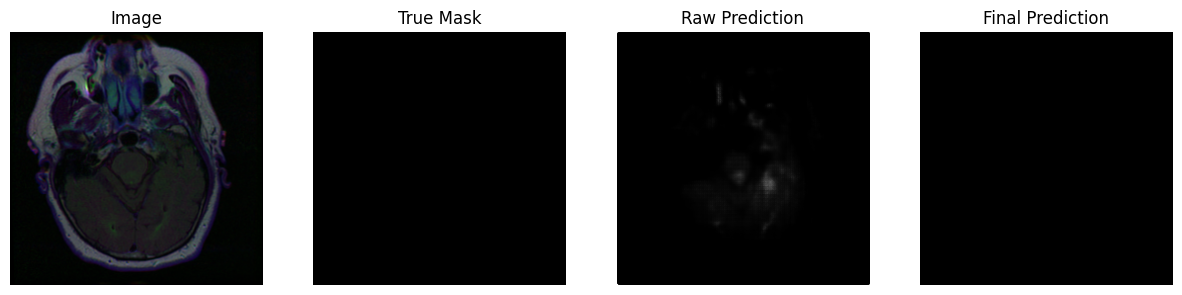

In [ ]:
import random

idx = random.randint(44
                     , len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img, pred = predict_image(img_path)
true_mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(pred.squeeze(), cmap='gray')
plt.title("Raw Prediction")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(pred.squeeze() > 0.2, cmap='gray')
plt.title("Final Prediction")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


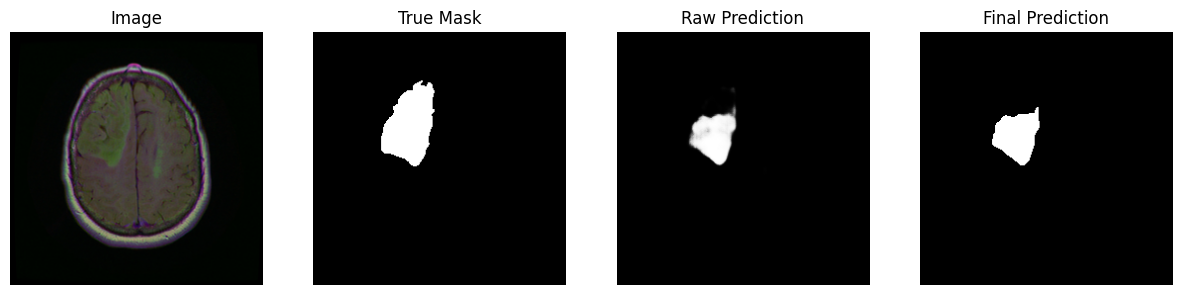

In [ ]:
import random

idx = random.randint(56, len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img, pred = predict_image(img_path)
true_mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(pred.squeeze(), cmap='gray')
plt.title("Raw Prediction")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(pred.squeeze() > 0.2, cmap='gray')
plt.title("Final Prediction")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


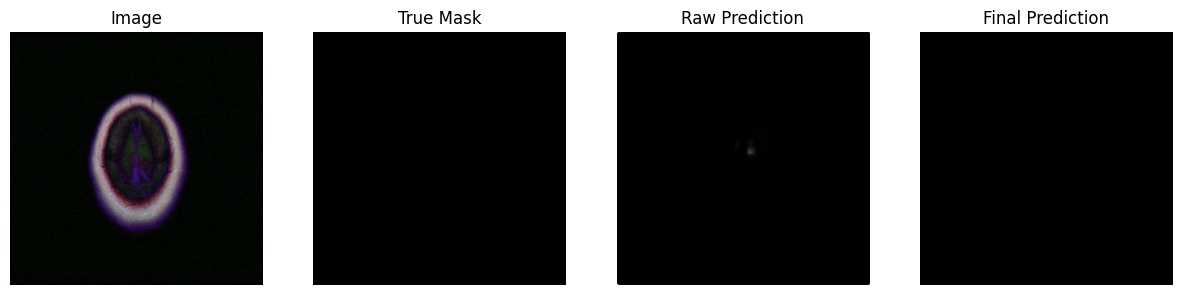

In [ ]:
import random

idx = random.randint(95, len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img, pred = predict_image(img_path)
true_mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(pred.squeeze(), cmap='gray')
plt.title("Raw Prediction")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(pred.squeeze() > 0.2, cmap='gray')
plt.title("Final Prediction")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


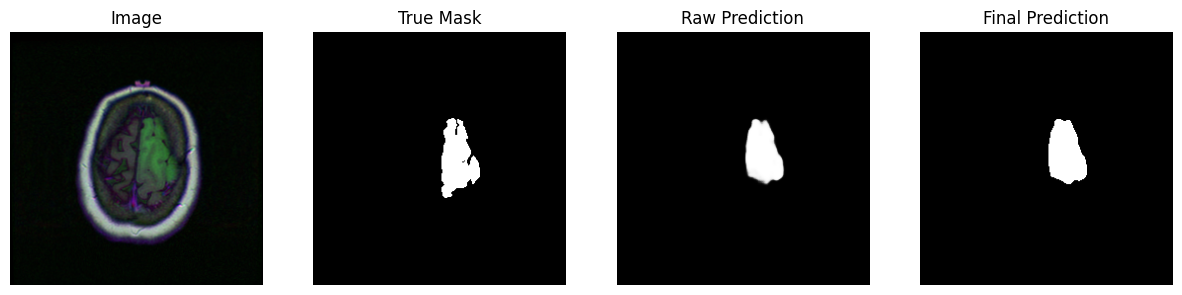

In [ ]:
import random

idx = random.randint(65, len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img, pred = predict_image(img_path)
true_mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(pred.squeeze(), cmap='gray')
plt.title("Raw Prediction")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(pred.squeeze() > 0.2, cmap='gray')
plt.title("Final Prediction")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


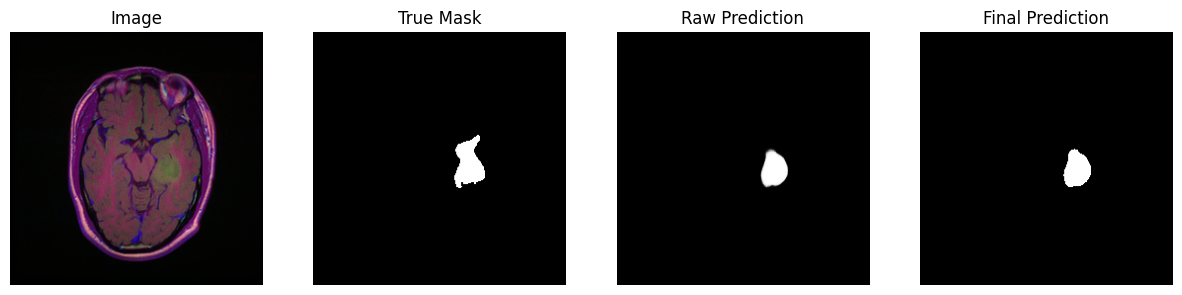

In [ ]:
import random

idx = random.randint(23, len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img, pred = predict_image(img_path)
true_mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(pred.squeeze(), cmap='gray')
plt.title("Raw Prediction")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(pred.squeeze() > 0.2, cmap='gray')
plt.title("Final Prediction")
plt.axis('off')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history, save_path="/content/drive/MyDrive/plots/"):
    os.makedirs(save_path, exist_ok=True)

    # 🔹 Loss Plot
    plt.figure(figsize=(10,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid()

    plt.savefig(save_path + "loss_plot.png")
    plt.show()

    # 🔹 Dice Plot
    plt.figure(figsize=(10,5))
    plt.plot(history.history['dice_coef'], label='Train Dice')
    plt.plot(history.history['val_dice_coef'], label='Val Dice')
    plt.legend()
    plt.title("Dice Score vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Dice Score")
    plt.grid()

    plt.savefig(save_path + "dice_plot.png")
    plt.show()

In [ ]:
def show_predictions_grid(model, df, num_samples=6, save_path="/content/drive/MyDrive/plots/"):
    os.makedirs(save_path, exist_ok=True)

    plt.figure(figsize=(12, num_samples*3))

    for i in range(num_samples):
        idx = np.random.randint(0, len(df))
        img_path = df['images_paths'].iloc[idx]
        mask_path = df['masks_paths'].iloc[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img,(256,256))/255.0

        pred = model.predict(np.expand_dims(img_resized,0))[0]

        true_mask = cv2.imread(mask_path, 0)

        # Original
        plt.subplot(num_samples,3,i*3+1)
        plt.imshow(img_resized)
        plt.title("Image")
        plt.axis('off')

        # Ground Truth
        plt.subplot(num_samples,3,i*3+2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("True Mask")
        plt.axis('off')

        # Prediction
        plt.subplot(num_samples,3,i*3+3)
        plt.imshow(pred>0.2, cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(save_path + "predictions_grid.png")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


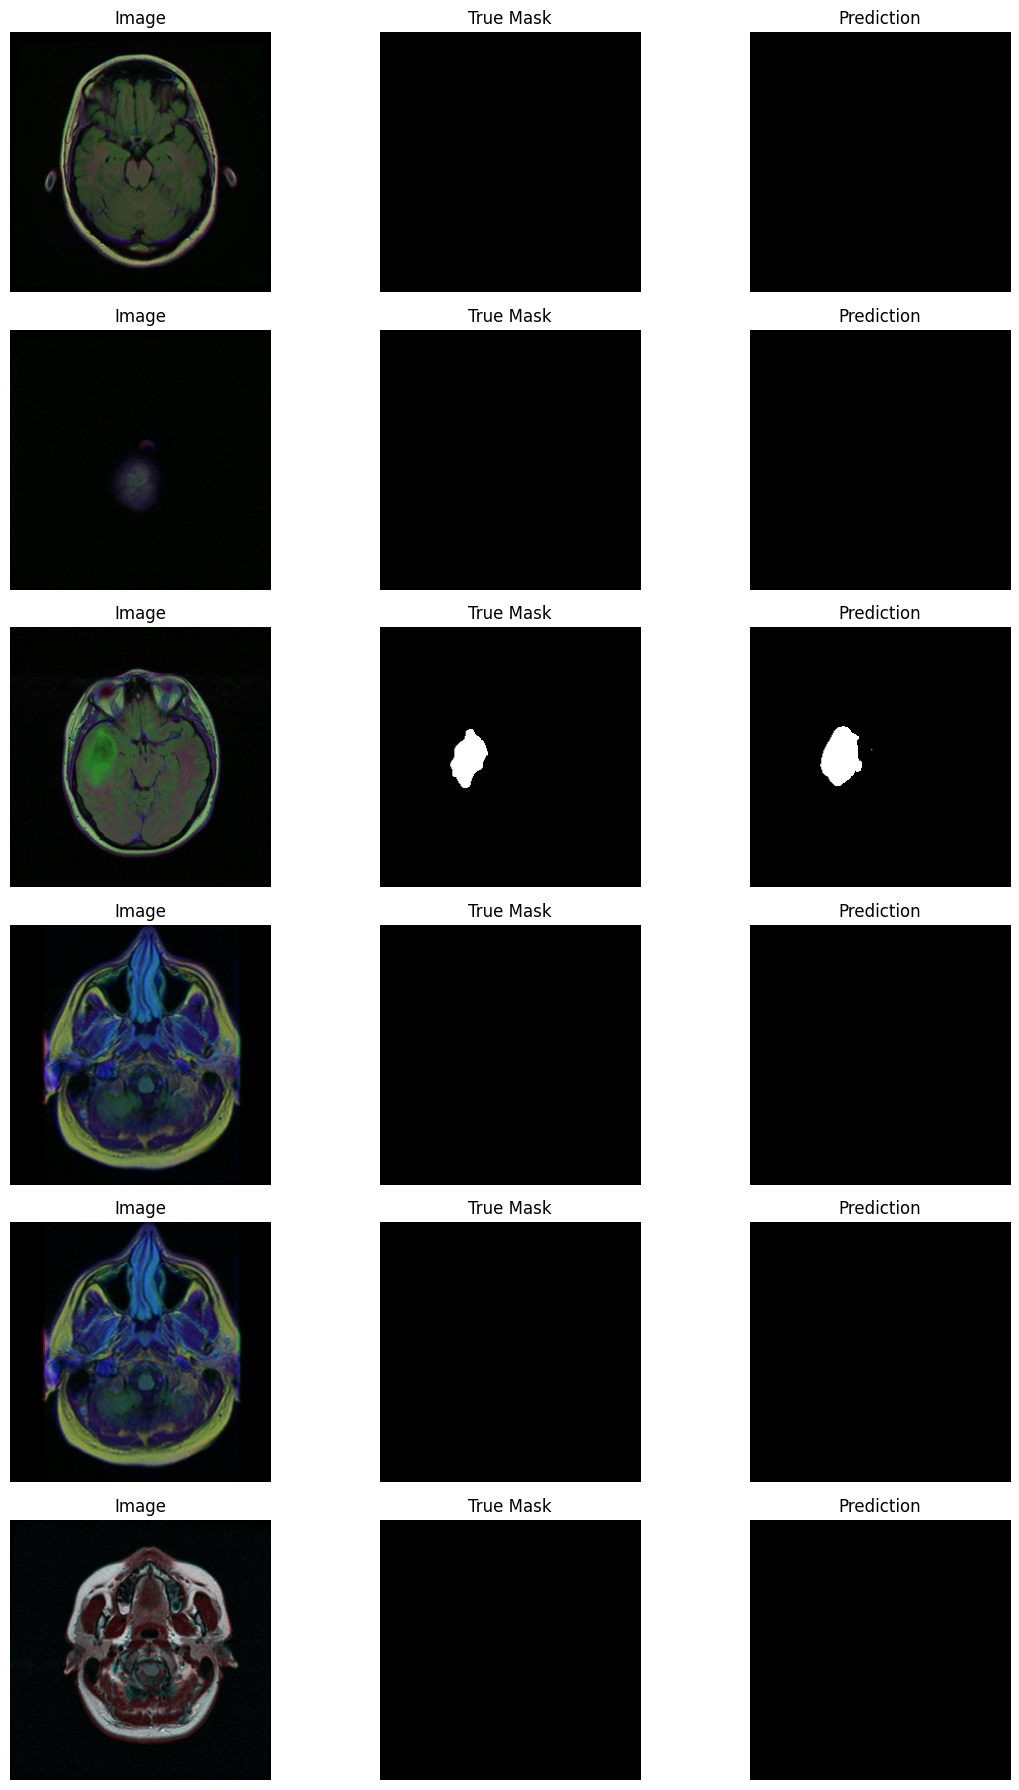

In [ ]:
show_predictions_grid(model, test_df)

In [ ]:
def overlay_prediction(model, df, save_path="/content/drive/MyDrive/plots/"):
    os.makedirs(save_path, exist_ok=True)

    idx = np.random.randint(0, len(df))

    img_path = df['images_paths'].iloc[idx]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img,(256,256))/255.0

    pred = model.predict(np.expand_dims(img_resized,0))[0]
    mask = (pred > 0.2).astype(np.uint8)

    plt.figure(figsize=(6,6))
    plt.imshow(img_resized)
    plt.imshow(mask.squeeze(), alpha=0.4, cmap='jet')
    plt.title("Tumor Overlay")
    plt.axis('off')

    plt.savefig(save_path + "overlay.png")
    plt.show()

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_all_metrics(history, save_path="outputs/plots/"):
    os.makedirs(save_path, exist_ok=True)

    # Extract metrics
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    dice = history.history.get('dice_coef', [])
    val_dice = history.history.get('val_dice_coef', [])

    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])

    epochs = range(1, len(loss) + 1)

    # 🔹 BEST POINTS
    best_loss_epoch = np.argmin(val_loss) + 1
    best_dice_epoch = np.argmax(val_dice) + 1 if len(val_dice) > 0 else None


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure save_path directory exists
save_path = "/content/drive/MyDrive/plots/"
os.makedirs(save_path, exist_ok=True)

# The 'history' object must be defined from model training (e.g., cell 5LZrpoZnJGnE).
# If the model has not been trained or the kernel reset, 'history' will be undefined.

# Call the existing plot_training function if history is available.
if 'history' in globals():
    plot_training(history, save_path)
else:
    print("Error: The 'history' object is not defined. Please run the model training cell (5LZrpoZnJGnE) first to generate the training history.")


Error: The 'history' object is not defined. Please run the model training cell (5LZrpoZnJGnE) first to generate the training history.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_all_metrics(history, save_path="outputs/plots/"):
    os.makedirs(save_path, exist_ok=True)

    # Extract metrics
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    dice = history.history.get('dice_coef', [])
    val_dice = history.history.get('val_dice_coef', [])

    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])

    epochs = range(1, len(loss) + 1)

    # 🔹 BEST POINTS
    best_loss_epoch = np.argmin(val_loss) + 1
    best_dice_epoch = np.argmax(val_dice) + 1 if len(val_dice) > 0 else None

    # ===============================
    # 🔹 LOSS PLOT
    # ===============================
    plt.figure(figsize=(10,5))
    plt.plot(epochs, loss, 'r-', label='Train Loss')
    plt.plot(epochs, val_loss, 'g-', label='Val Loss')

    plt.scatter(best_loss_epoch, val_loss[best_loss_epoch-1],
                color='blue', s=150, label=f'Best Epoch: {best_loss_epoch}')

    plt.title("Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.savefig(save_path + "loss_plot.png")
    plt.show()

    # ===============================
    # 🔹 DICE PLOT
    # ===============================
    if len(dice) > 0:
        plt.figure(figsize=(10,5))
        plt.plot(epochs, dice, 'r-', label='Train Dice')
        plt.plot(epochs, val_dice, 'g-', label='Val Dice')

        if best_dice_epoch:
            plt.scatter(best_dice_epoch, val_dice[best_dice_epoch-1],
                        color='blue', s=150, label=f'Best Epoch: {best_dice_epoch}')

        plt.title("Dice Score vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Dice Score")
        plt.legend()
        plt.grid()

        plt.savefig(save_path + "dice_plot.png")
        plt.show()

    # ===============================
    # 🔹 ACCURACY PLOT
    # ===============================
    if len(acc) > 0:
        plt.figure(figsize=(10,5))
        plt.plot(epochs, acc, 'r-', label='Train Accuracy')
        plt.plot(epochs, val_acc, 'g-', label='Val Accuracy')

        plt.title("Accuracy vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid()

        plt.savefig(save_path + "accuracy_plot.png")
        plt.show()

    # ===============================
    # 🔹 COMBINED PLOT (🔥 BEST FOR README)
    # ===============================
    plt.figure(figsize=(12,8))

    # Loss
    plt.subplot(2,1,1)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title("Loss Curve")
    plt.legend()
    plt.grid()

    # Dice
    if len(dice) > 0:
        plt.subplot(2,1,2)
        plt.plot(epochs, dice, label='Train Dice')
        plt.plot(epochs, val_dice, label='Val Dice')
        plt.title("Dice Curve")
        plt.legend()
        plt.grid()

    plt.tight_layout()
    plt.savefig(save_path + "combined_plot.png")
    plt.show()

In [ ]:
def plot_prediction_histogram(pred):
    plt.hist(pred.flatten(), bins=50)
    plt.title("Prediction Value Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()